In [2]:
from ultralytics import YOLO

# Load pre-trained segmentation model
model = YOLO("yolov8n-seg.pt")  # you can also use yolov8s-seg.pt, yolov8m-seg.pt

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Hashir\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
# Run inference
results = model(r"E:\Computer Vision\LAB\lab11\cycling.jpg")  # replace with your image path



image 1/1 E:\Computer Vision\LAB\lab11\cycling.jpg: 448x640 1 person, 3 bicycles, 1 car, 450.1ms
Speed: 29.1ms preprocess, 450.1ms inference, 161.5ms postprocess per image at shape (1, 3, 448, 640)


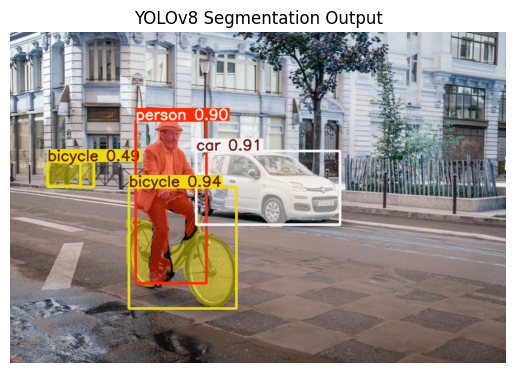

In [7]:
import matplotlib.pyplot as plt

# Plot result (includes masks, boxes, labels)
result = results[0]
annotated_img = result.plot()

plt.imshow(annotated_img)
plt.axis("off")
plt.title("YOLOv8 Segmentation Output")
plt.show()

In [1]:
import cv2
from ultralytics import YOLO

# Load YOLOv8 segmentation model
model = YOLO("yolov8n-seg.pt")  # use yolov8s-seg.pt for better accuracy

# Open webcam (0 = default camera)
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Cannot access webcam")
    exit()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Run segmentation on frame
    results = model(frame)

    # Get annotated frame (with masks, boxes, labels)
    annotated_frame = results[0].plot()

    # Display output
    cv2.imshow("YOLOv8 Segmentation - Webcam", annotated_frame)

    # Press 'q' to quit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
cv2.destroyAllWindows()


0: 480x640 1 person, 610.5ms
Speed: 13.7ms preprocess, 610.5ms inference, 43.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 321.2ms
Speed: 6.1ms preprocess, 321.2ms inference, 11.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 295.3ms
Speed: 4.0ms preprocess, 295.3ms inference, 7.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 291.2ms
Speed: 3.0ms preprocess, 291.2ms inference, 8.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 265.3ms
Speed: 3.4ms preprocess, 265.3ms inference, 8.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 297.1ms
Speed: 2.8ms preprocess, 297.1ms inference, 5.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 209.8ms
Speed: 2.8ms preprocess, 209.8ms inference, 5.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 197.5ms
Speed: 2.4ms preprocess, 197.5ms inference, 6.1ms postprocess per image

In [ ]:
# ============================================================
# 1. IMPORTS
# ============================================================
from ultralytics import YOLO
import matplotlib.pyplot as plt
import os
import yaml
import pandas as pd

# ============================================================
# 2. DATASET ROOT
# ============================================================

DATASET_ROOT = r"E:\Computer Vision\LAB\lab11\dataset"

# ============================================================
# 3. VERIFY DATASET STRUCTURE (ROBoflow STYLE)
# ============================================================

required_paths = [
    os.path.join(DATASET_ROOT, "train", "images"),
    os.path.join(DATASET_ROOT, "train", "labels"),
    os.path.join(DATASET_ROOT, "valid", "images"),
    os.path.join(DATASET_ROOT, "valid", "labels"),
]

for path in required_paths:
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ Missing folder: {path}")

print("✅ Dataset structure verified!")

# ============================================================
# 4. CREATE CORRECT data.yaml
# ============================================================

data_config = {
    'path': DATASET_ROOT,
    'train': 'train/images',
    'val': 'valid/images',   # ⚠️ IMPORTANT FIX
    'nc': 1,
    'names': ['pothole']
}

yaml_path = os.path.join(DATASET_ROOT, "data.yaml")

with open(yaml_path, "w") as f:
    yaml.dump(data_config, f)

print("✅ data.yaml created at:", yaml_path)

# ============================================================
# 5. LOAD MODEL
# ============================================================

model = YOLO("yolov8n-seg.pt")

# ============================================================
# 6. TRAIN MODEL
# ============================================================

results = model.train(
    data=yaml_path,
    epochs=20,
    imgsz=640,
    batch=8,
    name="pothole_seg_model"
)

# ============================================================
# 7. EVALUATE MODEL
# ============================================================

metrics = model.val(data=yaml_path)

print("\n===== SEGMENTATION METRICS =====")
print(f"mAP@0.5: {metrics.seg.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.seg.map:.4f}")
print(f"Precision: {metrics.seg.mp:.4f}")
print(f"Recall: {metrics.seg.mr:.4f}")

# ============================================================
# 8. INFERENCE ON UNSEEN IMAGES
# ============================================================

test_folder = os.path.join(DATASET_ROOT, "valid", "images")

results = model.predict(
    source=test_folder,
    conf=0.25,
    save=True
)

print("✅ Predictions saved in runs/segment/predict/")

# ============================================================
# 9. DISPLAY RESULTS (LIMITED)
# ============================================================

for r in results[:5]:  # show first 5 only
    img = r.plot()
    plt.imshow(img)
    plt.axis("off")
    plt.title("Segmentation Result")
    plt.show()

# ============================================================
# 10. PLOT TRAINING CURVES
# ============================================================

results_csv = "runs/segment/pothole_seg_model/results.csv"

if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)

    # Loss curves
    plt.figure()
    plt.plot(df['train/box_loss'], label='Train Box Loss')
    plt.plot(df['train/seg_loss'], label='Train Seg Loss')
    plt.plot(df['val/box_loss'], label='Val Box Loss')
    plt.plot(df['val/seg_loss'], label='Val Seg Loss')
    plt.legend()
    plt.title("Training & Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    # Segmentation mAP curves
    if 'metrics/mAP50(M)' in df.columns:
        plt.figure()
        plt.plot(df['metrics/mAP50(M)'], label='Seg mAP@0.5')
        plt.plot(df['metrics/mAP50-95(M)'], label='Seg mAP@0.5:0.95')
        plt.legend()
        plt.title("Segmentation mAP")
        plt.xlabel("Epoch")
        plt.ylabel("mAP")
        plt.show()

else:
    print("⚠️ results.csv not found. Training may not have completed.")

# ============================================================
# DONE
# ============================================================

✅ Dataset structure verified!
✅ data.yaml created at: E:\Computer Vision\LAB\lab11\dataset\data.yaml
New https://pypi.org/project/ultralytics/8.4.45 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.41  Python-3.11.6 torch-2.10.0+cpu CPU (11th Gen Intel Core i5-1135G7 @ 2.40GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\Computer Vision\LAB\lab11\dataset\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, 